In [17]:
!pip install -q transformers torch torchvision pillow scikit-learn matplotlib requests

In [18]:
import os
import requests
from io import BytesIO

import torch
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
from sklearn.metrics.pairwise import cosine_similarity

from transformers import AutoImageProcessor, AutoModel

device = "cuda" if torch.cuda.is_available() else "cpu"
device

'cpu'

In [19]:
# Pretrained feature extractor: ResNet-50 (Hugging Face)
MODEL_NAME = "microsoft/resnet-50"

processor = AutoImageProcessor.from_pretrained(MODEL_NAME)
model = AutoModel.from_pretrained(MODEL_NAME).to(device)
model.eval()

Loading weights:   0%|          | 0/318 [00:00<?, ?it/s]

[transformers] ResNetModel LOAD REPORT from: microsoft/resnet-50
Key                 | Status     |  | 
--------------------+------------+--+-
classifier.1.bias   | UNEXPECTED |  | 
classifier.1.weight | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


ResNetModel(
  (embedder): ResNetEmbeddings(
    (embedder): ResNetConvLayer(
      (convolution): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
      (normalization): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
      (activation): ReLU()
    )
    (pooler): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  )
  (encoder): ResNetEncoder(
    (stages): ModuleList(
      (0): ResNetStage(
        (layers): Sequential(
          (0): ResNetBottleNeckLayer(
            (shortcut): ResNetShortCut(
              (convolution): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 1), bias=False)
              (normalization): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
            )
            (layer): Sequential(
              (0): ResNetConvLayer(
                (convolution): Conv2d(64, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
       

In [20]:
def load_image(path_or_url):
    """Load an image from a local path or a URL."""
    if path_or_url.startswith("http"):
        resp = requests.get(path_or_url, timeout=10)
        img = Image.open(BytesIO(resp.content)).convert("RGB")
    else:
        img = Image.open(path_or_url).convert("RGB")
    return img


def get_embedding(img):
    """Return a single pooled feature vector (numpy array) for an image."""
    inputs = processor(images=img, return_tensors="pt").to(device)
    with torch.no_grad():
        outputs = model(**inputs)
    # pooler_output: (1, hidden_size) -> global average-pooled features
    feat = outputs.pooler_output.squeeze().cpu().numpy()
    return feat

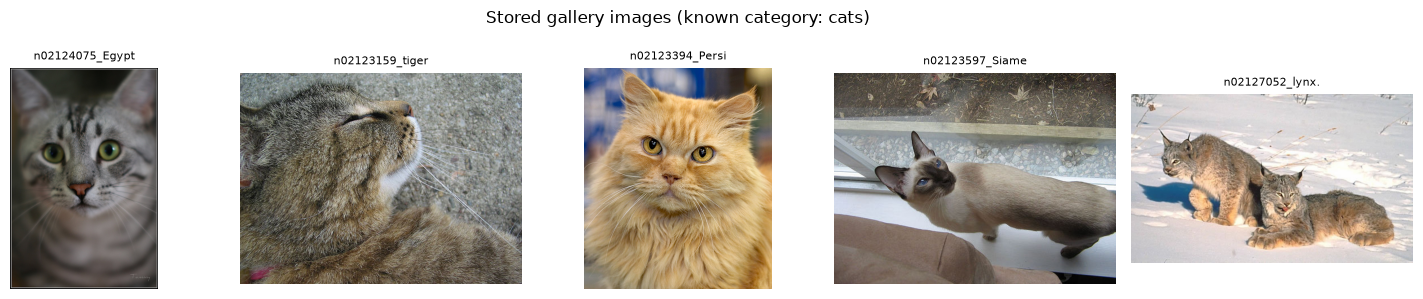

In [21]:
# ---- Step 3: small gallery of known images (one category: cats) ----
cat_image_urls = [
    "https://raw.githubusercontent.com/EliSchwartz/imagenet-sample-images/master/n02124075_Egyptian_cat.JPEG",
    "https://raw.githubusercontent.com/EliSchwartz/imagenet-sample-images/master/n02123159_tiger_cat.JPEG",
    "https://raw.githubusercontent.com/EliSchwartz/imagenet-sample-images/master/n02123394_Persian_cat.JPEG",
    "https://raw.githubusercontent.com/EliSchwartz/imagenet-sample-images/master/n02123597_Siamese_cat.JPEG",
    "https://raw.githubusercontent.com/EliSchwartz/imagenet-sample-images/master/n02127052_lynx.JPEG",
]

gallery_images = [load_image(u) for u in cat_image_urls]

fig, axes = plt.subplots(1, len(gallery_images), figsize=(15, 3))
for ax, img, url in zip(axes, gallery_images, cat_image_urls):
    ax.imshow(img)
    ax.set_title(url.split("/")[-1][:15], fontsize=8)
    ax.axis("off")
plt.suptitle("Stored gallery images (known category: cats)")
plt.tight_layout()
plt.show()

In [22]:
# ---- Step 4: extract feature vectors for every gallery image ----
gallery_embeddings = np.stack([get_embedding(img) for img in gallery_images])
print("Gallery embeddings shape:", gallery_embeddings.shape)

Gallery embeddings shape: (5, 2048)


In [23]:
def find_most_similar(query_url):
    """Compare a new image against the gallery and return the best match + score."""
    query_img = load_image(query_url)
    query_emb = get_embedding(query_img).reshape(1, -1)

    sims = cosine_similarity(query_emb, gallery_embeddings)[0]
    best_idx = int(np.argmax(sims))
    best_score = float(sims[best_idx])

    fig, axes = plt.subplots(1, 2, figsize=(6, 3))
    axes[0].imshow(query_img)
    axes[0].set_title("Input image")
    axes[0].axis("off")

    axes[1].imshow(gallery_images[best_idx])
    axes[1].set_title(f"Most similar\nscore={best_score:.3f}")
    axes[1].axis("off")
    plt.show()

    print(f"Similarity score: {best_score:.4f}")
    if best_score > 0.85:
        print("=> Verdict: SIMILAR to known category (normal)")
    else:
        print("=> Verdict: UNUSUAL / possible anomaly")

    return best_idx, best_score

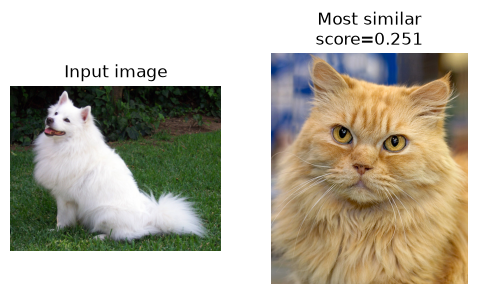

Similarity score: 0.2508
=> Verdict: UNUSUAL / possible anomaly


(2, 0.25077328085899353)

In [24]:
# ---- Test with an image from a COMPLETELY DIFFERENT category (dog) ----
different_category_url = "https://raw.githubusercontent.com/pytorch/hub/master/images/dog.jpg"
find_most_similar(different_category_url)